<a href="https://colab.research.google.com/github/faudhim5-buddy/belajar-ai-30-hari/blob/main/Day_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install groq

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error
from sklearn.neighbors import NearestNeighbors

data_buku = {
    "judul" : [
        "Bumi Manusia", "Laskar Pelangi", "Negeri 5 Menara",
        "Ayat-Ayat Cinta", "Harry Potter", "The Alchemist",
        "Rich Dad Poor Dad", "Atomic Habits", "Clean Code",
        "Python Crash Course", "Dune", "1984",
        "Sapiens", "Deep Work", "The Pragmatic Programmer"
    ],
    "genre" : [
        "fiksi sejarah", "fiksi", "fiksi islami",
        "fiksi islami", "fantasi", "fiksi motivasi",
        "nonfiksi keuangan", "nonfiksi pengembangan diri",
        "nonfiksi teknologi", "nonfiksi teknologi",
        "fantasi", "fiksi distopia",
        "nonfiksi sejarah", "nonfiksi pengembangan diri",
        "nonfiksi teknologi"
    ],
    "rating": [
        4.8, 4.7, 4.6, 4.5, 4.9, 4.7, 4.6, 4.8, 4.5, 4.6,
        4.8, 4.7, 4.7, 4.6, 4.5
    ],
    "jumlah_halaman" : [
        535, 529, 423, 411, 309, 208, 336, 320, 431, 544,
        688, 328, 443, 296, 352
    ],
    "tahun" : [
        1980, 2005, 2009, 2004, 1997, 1988, 1997, 2018, 2008, 2015,
        1965, 1949, 2011, 2016, 1999
    ],
    "populer" : [
        "ya", "ya", "ya", "ya", "ya", "ya", "ya", "ya",
        "tidak", "tidak", "ya", "ya", "ya", "tidak", "tidak"
    ],
}

df = pd.DataFrame(data_buku)
print("Dataset berhasil dimuat!")
print(f"Jumlah buku : {len(df)}")
print(f"Jumlah genre unik: {df['genre'].nunique()}")

print()
print(df.head())


Dataset berhasil dimuat!
Jumlah buku : 15
Jumlah genre unik: 10

             judul          genre  rating  jumlah_halaman  tahun populer
0     Bumi Manusia  fiksi sejarah     4.8             535   1980      ya
1   Laskar Pelangi          fiksi     4.7             529   2005      ya
2  Negeri 5 Menara   fiksi islami     4.6             423   2009      ya
3  Ayat-Ayat Cinta   fiksi islami     4.5             411   2004      ya
4     Harry Potter        fantasi     4.9             309   1997      ya


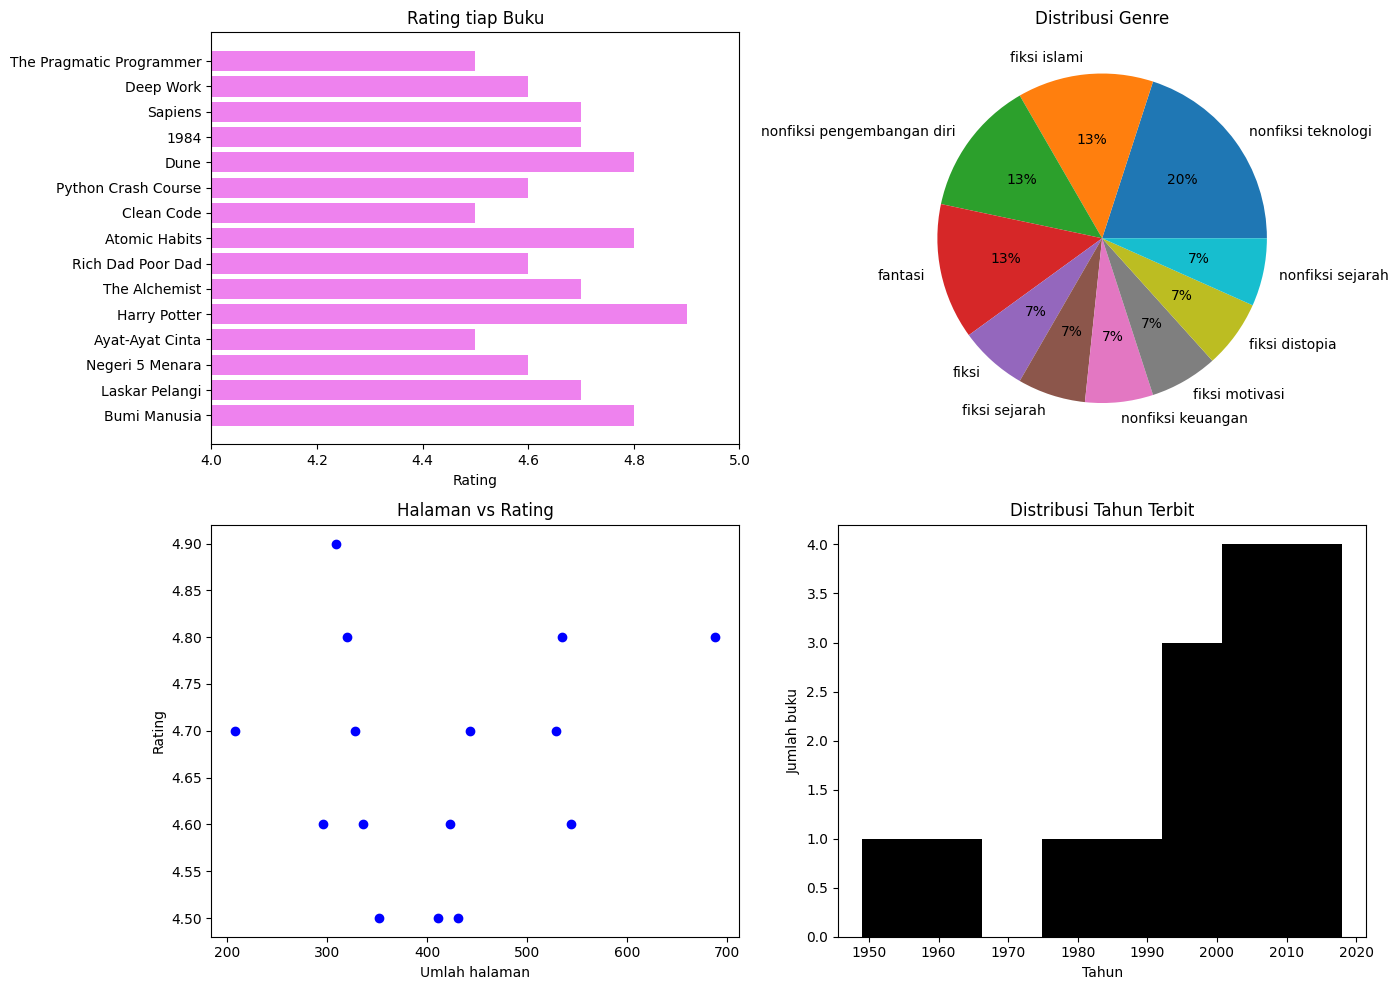

Statistik Dateset
Rating rata-rata: 4.67
Buku terpanjang: Dune (688 hal)
Buku terpendek: The Alchemist (208 hal)
Buku tertua: 1984 (1949)


In [7]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

axes[0,0].barh(df["judul"], df["rating"], color="violet")
axes[0,0].set_title("Rating tiap Buku")
axes[0,0].set_xlim(4.0, 5.0)
axes[0,0].set_xlabel("Rating")

genre_count = df["genre"].value_counts()
axes[0, 1].pie(genre_count.values,
               labels=genre_count.index,
               autopct="%1.0f%%")
axes[0, 1].set_title("Distribusi Genre")

axes[1,0].scatter(df["jumlah_halaman"], df["rating"], color="blue")
axes[1,0].set_title("Halaman vs Rating")
axes[1,0].set_xlabel("Umlah halaman")
axes[1,0].set_ylabel("Rating")

axes[1,1].hist(df["tahun"], bins=8, color="black")
axes[1,1].set_title("Distribusi Tahun Terbit")
axes[1,1].set_xlabel("Tahun")
axes[1,1].set_ylabel("Jumlah buku")

plt.tight_layout()
plt.show()

print("Statistik Dateset")
print(f"Rating rata-rata: {df['rating'].mean():.2f}")
print(f"Buku terpanjang: {df.loc[df['jumlah_halaman'].idxmax(), 'judul']} ({df['jumlah_halaman'].max()} hal)" )
print(f"Buku terpendek: {df.loc[df['jumlah_halaman'].idxmin(), 'judul']} ({df['jumlah_halaman'].min()} hal)")
print(f"Buku tertua: {df.loc[df['tahun'].idxmin(), 'judul']} ({df['tahun'].min()})")

Akurasi prediksi popularitas: 100.0%



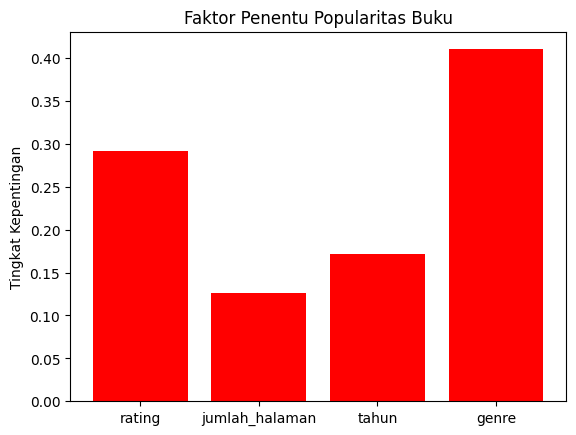

rating: 29.2%
jumlah_halaman: 12.6%
tahun: 17.2%
genre: 41.1%


In [19]:
le = LabelEncoder()
df["genre_encoded"] = le.fit_transform(df["genre"])

X = df[["rating", "jumlah_halaman", "tahun", "genre_encoded"]]
y= df["populer"]

X_latih, X_uji, y_latih, y_uji = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_latih_normal = scaler.fit_transform(X_latih)
X_uji_normal = scaler.transform(X_uji)

model_populer = RandomForestClassifier(n_estimators=100, random_state=42)
model_populer.fit(X_latih_normal, y_latih)

akurasi = accuracy_score(y_uji, model_populer.predict(X_uji_normal))
print(f"Akurasi prediksi popularitas: {akurasi *100:.1f}%")
print()

fitur = ["rating", "jumlah_halaman", "tahun", "genre"]
importance = model_populer.feature_importances_

plt.bar(fitur, importance, color="red")
plt.title("Faktor Penentu Popularitas Buku")
plt.ylabel("Tingkat Kepentingan")
plt.show()

for i, f in enumerate(fitur):
  print(f"{f}: {importance[i]*100:.1f}%")

In [18]:
from groq import Groq
from google.colab import userdata

groq_api_key = userdata.get('GROQ_API_KEY')

client = Groq(api_key=groq_api_key)

genre_encoded = pd.get_dummies(df["genre"])
fitur_numerik = df[["rating", "jumlah_halaman", "tahun"]]
X_rek = pd.concat([fitur_numerik, genre_encoded], axis=1)

scaler_rek = MinMaxScaler()
X_rek_normal = scaler_rek.fit_transform(X_rek)

X_weighted = X_rek_normal.copy()
X_weighted[:, 0] *= 0.5 #rating
X_weighted[:, 1] *= 0.3 #halaman
X_weighted[:, 2] *= 0.2 #tahun
X_weighted[:, 3:] *= 3.0 #genre

model_rek = NearestNeighbors(n_neighbors=4, metric="euclidean")
model_rek.fit(X_weighted)

def analisis_buku_dengan_ai(judul_buku):
  if judul_buku not in df["judul"].values:
    print(f"Buku '{judul_buku}' tidak ditemukan!")
    return

  buku = df[df["judul"] == judul_buku].iloc[0]

  idx = df[df["judul"] == judul_buku].index[0]
  jarak, indices = model_rek.kneighbors([X_weighted[idx]])
  rekomendasi = [df["judul"][i] for i in indices[0][1:]]

  fitur_buku_df = pd.DataFrame([[
      buku["rating"],
      buku["jumlah_halaman"],
      buku["tahun"],
      le.transform([buku["genre"]])[0]
  ]], columns=["rating", "jumlah_halaman", "tahun", "genre_encoded"])

  fitur_buku = scaler.transform(fitur_buku_df)
  populer_pred = model_populer.predict(fitur_buku)[0]

  prompt = f"""Berikan analisis singkat buku "{judul_buku}" dalam bahasa indonesia.
Format jawaban:
Deskripsi: [satu kalimat tentang buku ini]
Cocok untuk: [jenis pembaca yang cocok]
Pesan utama: [satu kalimat pesan terpenting]"""

  response = client.chat.completions.create(
          model="openai/gpt-oss-120b",
          messages=[{"role": "user", "content": prompt}]
      )
  analisis_ai = response.choices[0].message.content

  print("=" * 50)
  print(f"ANALISIS BUKU: {judul_buku}")
  print("=" * 50)
  print(f"Genre    : {buku['genre']}")
  print(f"Rating   : {buku['rating']}")
  print(f"Halaman  : {buku['jumlah_halaman']}")
  print(f"Tahun    : {int(buku['tahun'])}")
  print(f"Populer  : {populer_pred.upper()}")
  print()
  print("REKOMENDASI BUKU SERUPA:")

  for i, rek in enumerate(rekomendasi):
    print(f" {i+1}. {rek}")

  print()
  print("ANALISIS AI:")
  print(analisis_ai)

#test
analisis_buku_dengan_ai("Atomic Habits")
print()
analisis_buku_dengan_ai("Harry Potter")


ANALISIS BUKU: Atomic Habits
Genre    : nonfiksi pengembangan diri
Rating   : 4.8
Halaman  : 320
Tahun    : 2018
Populer  : YA

REKOMENDASI BUKU SERUPA:
 1. Deep Work
 2. Harry Potter
 3. Sapiens

ANALISIS AI:
Deskripsi: *Atomic Habits* mengajarkan cara membangun kebiasaan kecil yang konsisten untuk menghasilkan perubahan besar dalam hidup.  

Cocok untuk: pembaca yang ingin meningkatkan produktivitas, mengubah perilaku buruk, atau mengembangkan rutinitas positif, baik profesional maupun pribadi.  

Pesan utama: Perubahan signifikan datang dari perbaikan 1 % setiap hari; fokus pada sistem, bukan hanya tujuan.

ANALISIS BUKU: Harry Potter
Genre    : fantasi
Rating   : 4.9
Halaman  : 309
Tahun    : 1997
Populer  : YA

REKOMENDASI BUKU SERUPA:
 1. Dune
 2. Atomic Habits
 3. Bumi Manusia

ANALISIS AI:
**Deskripsi:** *Harry Potter* adalah seri novel fantasi yang mengikuti petualangan seorang anak yatim bernama Harry Potter di Sekolah Sihir Hogwarts, di mana ia belajar sihir, menjalin persah